In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'

# Set number of classes

In [3]:
NUM_CLASSES = 38


# Dataset reading

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])


In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout (Dropout)           (None, 42)                0         
                                                                 
 dense (Dense)               (None, 64)                2752      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 38)                1254      
                                                                 
Total params: 6086 (23.77 KB)
Trainable params: 6086 (23.77 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [11]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000


120/121 [============================>.] - ETA: 0s - loss: 3.0890 - accuracy: 0.1794
Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
121/121 [==============================] - 2s 8ms/step - loss: 3.0889 - accuracy: 0.1793 - val_loss: 2.3039 - val_accuracy: 0.3796
Epoch 2/1000
 49/121 [===========>..................] - ETA: 0s - loss: 2.3614 - accuracy: 0.3023

c:\Users\mohammed\ProjectStart\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


116/121 [===========================>..] - ETA: 0s - loss: 2.1875 - accuracy: 0.3419
Epoch 2: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
121/121 [==============================] - 1s 4ms/step - loss: 2.1829 - accuracy: 0.3423 - val_loss: 1.5626 - val_accuracy: 0.6132
Epoch 3/1000
119/121 [============================>.] - ETA: 0s - loss: 1.7813 - accuracy: 0.4437
Epoch 3: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
121/121 [==============================] - 1s 4ms/step - loss: 1.7803 - accuracy: 0.4439 - val_loss: 1.1989 - val_accuracy: 0.7882
Epoch 4/1000
120/121 [============================>.] - ETA: 0s - loss: 1.6097 - accuracy: 0.4928
Epoch 4: saving model to model/keypoint_classifier\keypoint_classifier.hdf5
121/121 [==============================] - 1s 4ms/step - loss: 1.6104 - accuracy: 0.4926 - val_loss: 1.0359 - val_accuracy: 0.7657
Epoch 5/1000
107/121 [=========================>....] - ETA: 0s - loss: 1.5064 - accuracy: 0.5296


In [12]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

41/41 [==============================] - 0s 2ms/step - loss: 0.3481 - accuracy: 0.9298


In [13]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [14]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 133ms/step
[5.8167509e-05 1.4375912e-07 1.2862765e-07 4.3363814e-04 8.9375884e-04
 7.4985361e-04 5.9151655e-04 3.8715305e-07 4.4215376e-06 6.1273738e-08
 6.9003626e-08 5.4863632e-01 4.2882475e-01 1.0852163e-02 1.2451768e-04
 3.6603348e-13 2.0638225e-14 9.8641655e-09 4.7850664e-11 2.0848143e-11
 6.0469392e-06 6.6188490e-04 1.9372911e-11 4.1764702e-06 1.8037169e-10
 8.1354864e-03 2.9187921e-08 5.9821491e-07 5.0935817e-10 1.5216122e-12
 3.1342540e-14 3.1688567e-12 1.0476729e-11 2.1488022e-05 1.3212588e-11
 9.1731299e-13 1.4617864e-11 4.1631858e-07]
11


# Confusion matrix

161/161 [==============================] - 0s 2ms/step


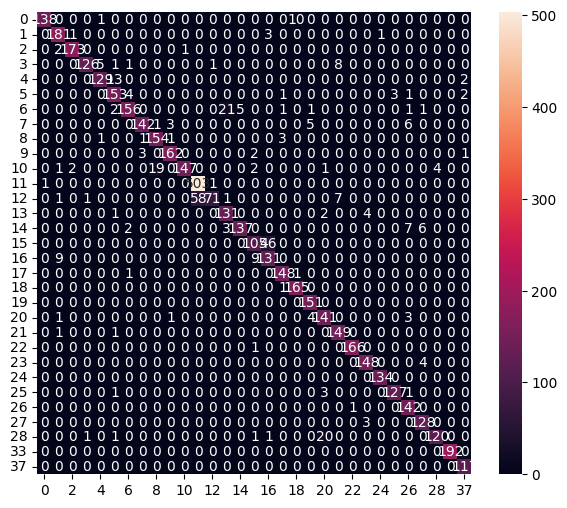

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       149
           1       0.92      0.97      0.95       186
           2       0.98      0.98      0.98       176
           3       0.98      0.89      0.93       142
           4       0.95      0.90      0.92       144
           5       0.88      0.93      0.91       164
           6       0.95      0.83      0.89       188
           7       0.97      0.90      0.94       157
           8       0.89      0.96      0.92       160
           9       0.97      0.96      0.97       168
          10       0.99      0.84      0.91       176
          11       0.90      1.00      0.94       505
          12       0.97      0.51      0.67       139
          13       0.84      0.95      0.89       138
          14       0.96      0.88      0.92       155
          15       0.88      0.70      0.77       151
          16       0.72      0.88      0.79       149
     

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [16]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

c:\Users\mohammed\ProjectStart\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [17]:
# Transform model (quantization)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\mohammed\AppData\Local\Temp\tmpqe1nk2q8\assets


INFO:tensorflow:Assets written to: C:\Users\mohammed\AppData\Local\Temp\tmpqe1nk2q8\assets


8752

# Inference test

In [18]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [19]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [20]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [21]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 0 ns


In [ ]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[5.28430028e-05 1.31825701e-07 9.06795918e-08 3.82292143e-04
 8.62593006e-04 7.32155982e-04 4.36882488e-04 3.07416400e-07
 3.28425676e-06 4.60043417e-08 5.25255786e-08 5.61769962e-01
 4.18176919e-01 9.49697848e-03 1.05884086e-04 2.87090853e-13
 1.74721179e-14 9.00878838e-09 3.70755475e-11 1.72664470e-11
 5.01965496e-06 6.20056700e-04 1.61462458e-11 3.90299010e-06
 1.52915430e-10 7.33066211e-03 2.64751705e-08 5.10273878e-07
 3.76462111e-10 1.16780207e-12 2.33538503e-14 2.58953883e-12
 9.02616263e-12 1.89250586e-05 1.23695134e-11 8.19921496e-13
 1.33462937e-11 4.36258489e-07]
11


: 